In [1]:
from tensorflow.keras import layers, models

class AE(models.Model):
    # input 784 => hidden 36 => output 784
    # 24x24(픽셀 784개) 입력 이미지가 36개의 벡터로 변환되고 24x24 이미지로 복구된다.
                        #전달된 값이 없을 때 기본값 784, 36
    def __init__(self, x_nodes=784, z_dim=36):
        x_shape = (x_nodes,)
        x = layers.Input(shape=x_shape)
        z = layers.Dense(z_dim, activation='relu')(x)
        y = layers.Dense(x_nodes, activation='sigmoid')(z)
        super().__init__(x,y)
        self.x = x
        self.z = z
        self.z_dim = z_dim

        self.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    def Encoder(self):
        return models.Model(self.x, self.z)

    def Decoder(self):
        z_shape = (self.z_dim,)
        z = layers.Input(shape=z_shape)
        y_layer = self.layers[-1]
        y = y_layer(z)
        return models.Model(z,y)

In [2]:
from tensorflow.keras.datasets import mnist

(X_train, _), (X_test, _) = mnist.load_data()
        # _ 사용하지 않는 변수(y)
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.
print(X_train.shape)

(60000, 28, 28)


In [14]:
# len(X_train) 이미지수, np.prod(X_train.shape[1:]) 이미지 길이
print(X_train.shape[1:]) #(28,28)

(784,)


In [4]:
X_train = X_train.reshape(len(X_train), 784)
X_test = X_test.reshape(len(X_test), 784)
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [5]:
#파라미터 설정(input 784 => hidden 36)
# 784 픽셀 이미지가 36 픽셀로 압축된다.
x_nodes = 784
z_dim = 36
autoencoder = AE(x_nodes, z_dim)

# 입력데이터와 출력데이터를 동일하게 설정한다.(X,y가 동일하다.)
# fit(입력데이터,출력데이터)
history = autoencoder.fit(X_train, X_train,
                          epochs=5,
                          batch_size=256,
                          validation_split=0.2,)

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0100 - loss: 0.2917 - val_accuracy: 0.0153 - val_loss: 0.1967
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0099 - loss: 0.1761 - val_accuracy: 0.0111 - val_loss: 0.1597
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0109 - loss: 0.1498 - val_accuracy: 0.0113 - val_loss: 0.1404
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0099 - loss: 0.1337 - val_accuracy: 0.0093 - val_loss: 0.1272
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0109 - loss: 0.1224 - val_accuracy: 0.0116 - val_loss: 0.1178


In [6]:
import matplotlib.pyplot as plt
def plot_acc(history, title=None):
    if not isinstance(history, dict):
        history = history.history
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    if title is not None:
        plt.title(title)
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['Train','Test'], loc=0)

In [7]:
import matplotlib.pyplot as plt
def plot_loss(history, title=None):
    if not isinstance(history, dict):
        history = history.history
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    if title is not None:
        plt.title(title)
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['Train','Test'], loc=0)

In [8]:
import matplotlib.pyplot as plt
def plot_loss_acc(history):
    plot_loss(history, 'Loss')
    plt.show()
    plot_acc(history, 'Accuracy')
    plt.show()

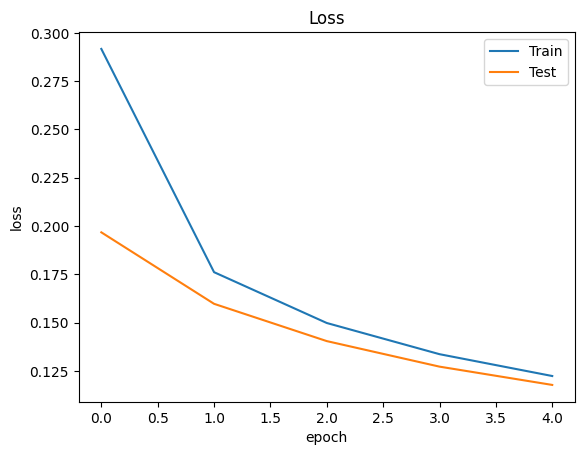

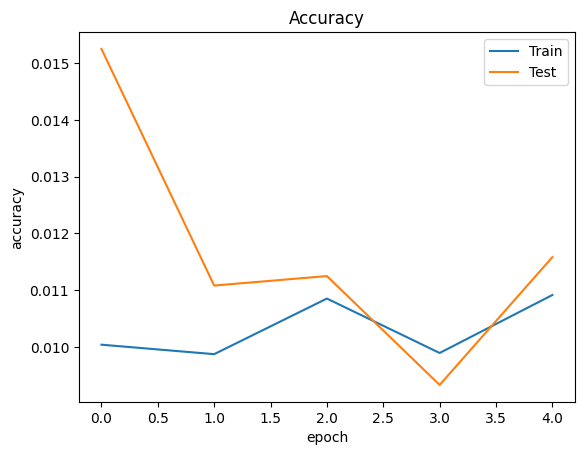

In [9]:
plot_loss_acc(history)

In [12]:
def show_ae(autoencoder):
    encoder = autoencoder.Encoder()
    decoder = autoencoder.Decoder()
    encoder.summary()
    decoder.summary()
    #검증용 이미지들을 넣어서 784=>36 압축
    encoded_imgs = encoder.predict(X_test)
    decoded_imgs = decoder.predict(encoded_imgs)

    n=10
    plt.figure(figsize=(20,6))
    for i in range(n):
        ax = plt.subplot(3, n, i+1)
        plt.imshow(X_test[i].reshape(28,28))
        plt.gray()
        #이미지 주변 축들이 보이지 않게 한다.
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        ax = plt.subplot(3, n, i+1+n)
        #2차원 이미지를 1차원의 벡터로 압축한다.
        plt.stem(encoded_imgs[i].reshape(-1))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        ax = plt.subplot(3, n, i+1+n+n)
        #복호화한 이미지를 출력한다.
        plt.imshow(decoded_imgs[i].reshape(28,28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 36)             │        28,260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,260 (110.39 KB)

 Trainable params: 28,260 (110.39 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 36)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        29,008 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,008 (113.31 KB)

 Trainable params: 29,008 (113.31 KB)

 Non-trainable params: 0 (0.00 B)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step


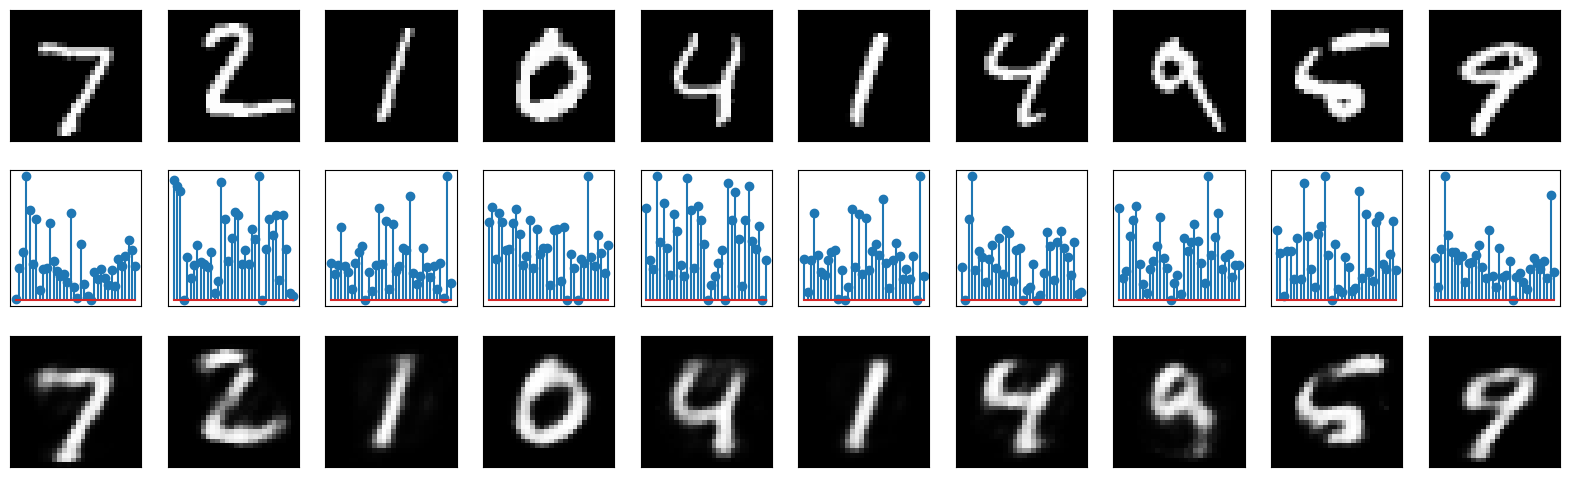

In [13]:
show_ae(autoencoder)